# 21 — Click Prediction with Proper Cross-Validation

Rigorous evaluation of cursor approach features for click prediction, fixing three methodological issues in notebook 15:
1. **Participant leakage** — random KFold puts same participant in train and test
2. **Scaler leakage** — StandardScaler.fit_transform() on all data before CV
3. **Missing intermediate baseline** — Position+dwell not reported

Follows Huang, White & Buscher (CHI 2012) leave-one-subject-out (LOSO) protocol.

**Output:** Updated numbers for paper §3.5 and §4.3, plus threshold analysis for the tautology fix.

## Key Claims (authoritative for paper writers)

*Last verified against executed notebook output: 2026-05-01.*
*Notebook: `21_click_prediction.ipynb`. Three feature flavors now coexist:*
- **Absolute (legacy)** — K1–K27, cursor-approach-features.json under absolute attribution
- **Organic-bbox** — K-bbox-1..K-bbox-12, cursor-approach-features-organic.json + organic regression labels (RECOMMENDED for paper figures)

### 2026-05-01 attribution shift — bbox primary

The LOSO classifier was retrained on `cursor-approach-features-organic.json` (14,760 records / 2,701 trials, +10% records / +15% trials over absolute) using `regression_labels_cache_organic.json` for the four-class taxonomy. Click prediction AUC tightens slightly; **position becomes more predictive under bbox attribution** (M1 AUC 0.613 → 0.727, +0.114) because organic-rank is the cleaner predictor than absolute-rank pooled with ads. Headline M3 LOSO AUC stays in the 0.859–0.865 range — the AR brand claim ("9 task-model-derived cursor features reach AUC ≈ 0.86 in LOSO") survives the cascade.

### Bbox-attribution K-IDs (RECOMMENDED for paper figures)

| ID | Claim | Value (organic-bbox) | Legacy (absolute) |
|---|---|---|---|
| **K-bbox-1** | Records / participants / click rate | **14,760 / 47 / 14.9%** (2,205 clicks) | 13,419 / 47 / 16.6% |
| **K-bbox-2** | Records per participant | similar shape; range pending re-summary | median 294, range 76–497 |
| **K-bbox-3** | **M3 LOSO AUC** (position + dwell + approach) | **0.865 (per-part std 0.044)** | 0.859 ± 0.044 |
| **K-bbox-4** | M4 LOSO AUC (approach only) | **0.864** | 0.861 |
| **K-bbox-5** | M2 LOSO AUC (position + dwell) | **0.784** | 0.743 |
| **K-bbox-6** | M1 LOSO AUC (position only) | **0.727** *(position is much more predictive under bbox; +0.114 over absolute)* | 0.613 |
| **K-bbox-7** | M3 LOSO AP | 0.575 *(slight decrease from 0.611 — under bbox, click rate is lower so AP baseline shifts)* | 0.611 |
| **K-bbox-8** | Leakage Δ (Random KFold − LOSO) | **+0.001 / +0.000 / +0.000** for M2/M3/M4 — essentially zero | +0.002 / −0.000 / −0.002 |
| **K-bbox-9** | Per-participant LOSO M3 AUC | **median 0.872, IQR [0.844, 0.886], range [0.732, 0.945]** | median 0.860, IQR [0.827, 0.901], range [0.745, 0.934] |
| **K-bbox-10** | Brier score (M3 OOF) | **0.1437** | 0.1526 |

### M3 feature coefficients under bbox (standardized, full-data refit)

| Feature | Bbox coefficient | Direction | Legacy |
|---|---|---|---|
| `min_dist` | **−0.737** | → skip | −0.904 |
| `final_dist` | **−0.805** | → skip | −0.967 |
| `dwell_in_proximity_ms` | **+0.763** | → click | +0.738 |
| `mean_dist` | **+0.522** | → click | +0.589 |
| `max_approach_velocity` | **+0.273** | → click | +0.207 |
| **`position`** | **−0.248** | → skip | −0.130 *(position became MORE predictive under bbox)* |
| `retreat_dist` | −0.191 | → skip | −0.206 |
| `direction_changes` | +0.087 | → click | +0.061 |
| `frac_decreasing` | +0.037 | → click | +0.031 |
| `mean_approach_velocity` | +0.005 | → click | +0.069 |
| `total_dwell_ms` | +0.011 | → click | −0.040 |

> **Bbox attribution is the recommended primary for paper figures.** The AR brand claim — "9 task-model-derived cursor features reach AUC ≈ 0.86 in LOSO" — survives and tightens under bbox. The position coefficient strengthens (−0.130 → −0.248): rank is a cleaner predictor when ads aren't pooled with organic. M1 AUC jumps from 0.613 to 0.727, which is paper-relevant: it means even position-alone is highly predictive once organic-rank is properly defined.
>
> **Four-class taxonomy under bbox attribution** is reported in NB22's K-bbox-* tier (label distribution shifts: 99.4% of trials see at least one shifted four-class label; 411 trials have shifted CLICKED count due to click reattribution). NB21's M3 classifier was retrained on the new features but uses the same architecture; its taxonomy outputs (deferred candidate / evaluated rejected) need a separate threshold pass for the new score distribution. Threshold values K10/K11 below are pre-cascade and need re-derivation.

---

### Legacy K-IDs (preserved for cross-reference)

| ID | Claim | Value |
|---|---|---|
| **K1** | Records / participants / click rate | **13,419 episodes / 47 participants / 16.6 % click rate** (2,228 clicks) |
| **K2** | Records per participant | **median 294, range 76–497** |
| **K3** | M3 (position + dwell + approach) pooled LOSO AUC | **0.859 ± 0.044** (47-fold) |
| **K4** | M4 (approach features only) LOSO AUC | **0.861 ± 0.043** |
| **K5** | M2 (position + dwell) LOSO AUC | **0.743 ± 0.076** |
| **K6** | M1 (position only) LOSO AUC | **0.613 ± 0.090** |
| **K7** | LOSO M3 AP | **0.611 ± 0.097** |
| **K8** | Leakage Δ (Random KFold − LOSO) for M2/M3/M4 | **+0.002 / −0.000 / −0.002** |
| **K9** | Per-participant LOSO M3 AUC | **median 0.860, IQR [0.827, 0.901], range [0.745, 0.934]** |
| **K10** | Youden's J threshold (M3 OOF) | *p* = **0.493** (TPR = **0.798**, FPR = **0.222**) — needs re-derivation under bbox |
| **K11** | F1-optimal threshold | *p* = **0.637**, F1 = **0.584** — needs re-derivation under bbox |
| **K12** | Brier score (M3 OOF) | **0.1526** |

### Four-class taxonomy (legacy under absolute)

| ID | Class | N | % | Mean *p*(click) |
|---|---|---|---|---|
| **K13** | Clicked | **2,228** | **16.6 %** | **0.690** |
| **K14** | Deferred candidate | **1,381** | **10.3 %** | **0.709** |
| **K15** | Evaluated-rejected | **974** | **7.3 %** | **0.313** |
| **K16** | No signal | **8,836** | **65.8 %** | **0.247** |

> **K13–K16 under bbox attribution are not yet derived in this iteration.** See NB22 K-bbox-* for the gaze-regression-label distribution shift; NB21's M3-classifier-derived taxonomy will follow when threshold re-derivation runs.

### M3 standardized feature coefficients (legacy, full-data refit) — superseded by bbox table above

| ID | Feature | Coefficient | Direction |
|---|---|---|---|
| **K17** | `mean_dist` | **+0.589** | → click |
| **K18** | `final_dist` | **−0.967** | → skip |
| **K19** | `dwell_in_proximity_ms` | **+0.738** | → click |
| **K20** | `min_dist` | **−0.904** | → skip |
| **K21** | `position` | **−0.130** | → skip |
| **K22** | `retreat_dist` | **−0.206** | → skip |
| **K23** | `mean_approach_velocity` | **+0.069** | → click |
| **K24** | `max_approach_velocity` | **+0.207** | → click |
| **K25** | `frac_decreasing` | **+0.031** | → click |
| **K26** | `total_dwell_ms` | **−0.040** | → skip |
| **K27** | `direction_changes` | **+0.061** | → click |

> **Robustness to individual cursor activity lives in NB11.5.** The chattiness-stratified AUC figure (§4.3 robustness paragraph of `docs/drafts/cikm-2026/paper.md`) uses [NB11_5:K9–K16], not NB21 directly.
>
> **Coordinate-space audit history (2026-04-09 / 2026-04-12).** Two prior audits: cursor-side scroll fix moved M3 AUC 0.827 → 0.792, then fixation-side FPOGY page-space audit moved M3 AUC 0.792 → 0.859 (records 15,397 → 13,419, click rate 14.4% → 16.6%). The 2026-05-01 AOI cascade then shifts to bbox attribution: records 13,419 → 14,760 (back up 10%), click rate 16.6% → 14.9%, M3 AUC 0.859 → 0.865. Direction of every headline preserved across all three audits.
>
> **Generated by `scripts/nb21_loso_retrain_organic.py`.** Full coefficients, per-participant AUCs, and KFold/LOSO leakage deltas land at `scripts/output/aoi-consumer-cascade/nb21_loso_organic.json`.

In [1]:
import json, sys, warnings
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, KFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore', category=UserWarning)

plt.rcParams.update({
    'figure.figsize': (10, 6), 'font.size': 12,
    'axes.spines.top': False, 'axes.spines.right': False
})

PLOT_DIR = Path('.')
DATA_PATH = Path('../AdSERP/data/cursor-approach-features.json')

In [2]:
# Load feature data
with open(DATA_PATH) as f:
    raw = json.load(f)

# Extract participant IDs
for r in raw:
    r['participant'] = r['trial_id'].split('-')[0]

# Build arrays
all_keys = raw[0].keys()
n = len(raw)

# Feature column groups
FEATURES_M1 = ['position']
FEATURES_M2 = ['position', 'total_dwell_ms']
FEATURES_M3 = ['position', 'total_dwell_ms',
               'min_dist', 'mean_dist', 'final_dist', 'retreat_dist',
               'dwell_in_proximity_ms', 'mean_approach_velocity',
               'max_approach_velocity', 'direction_changes', 'frac_decreasing']
FEATURES_M4 = ['min_dist', 'mean_dist', 'final_dist', 'retreat_dist',
               'dwell_in_proximity_ms', 'mean_approach_velocity',
               'max_approach_velocity', 'direction_changes', 'frac_decreasing']

def build_X(features):
    X = np.array([[r[f] for f in features] for r in raw], dtype=np.float64)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X

X_m1 = build_X(FEATURES_M1)
X_m2 = build_X(FEATURES_M2)
X_m3 = build_X(FEATURES_M3)
X_m4 = build_X(FEATURES_M4)
y = np.array([int(r['was_clicked']) for r in raw])

le = LabelEncoder()
groups = le.fit_transform([r['participant'] for r in raw])

print(f"Records: {n:,}")
print(f"Participants: {len(le.classes_)}")
print(f"Click rate: {y.mean():.3f} ({y.sum():,} / {n:,})")
print(f"Records/participant: median {np.median(np.bincount(groups)):.0f}, "
      f"range {np.bincount(groups).min()}–{np.bincount(groups).max()}")

Records: 13,419
Participants: 47
Click rate: 0.166 (2,228 / 13,419)
Records/participant: median 294, range 76–497


## 2. Evaluation Harness

`Pipeline(StandardScaler, LogisticRegression)` ensures the scaler fits only on training data within each fold. Three CV strategies as sensitivity analysis:
- **LOSO** (47-fold): gold standard, following Huang et al. (CHI 2012)
- **GroupKFold(5)**: grouped by participant, larger test folds
- **Random KFold(5)**: reproduces notebook 15 numbers (labeled as leaky baseline)

In [3]:
def evaluate_model(X, y, groups, cv, model_name=''):
    """Run CV with Pipeline. Returns per-fold metrics and out-of-fold predictions."""
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ])
    
    auc_scores, ap_scores = [], []
    y_pred_all = np.full(len(y), np.nan)
    fold_labels = np.full(len(y), -1, dtype=int)
    
    for fold_idx, (train_ix, test_ix) in enumerate(cv.split(X, y, groups)):
        pipe.fit(X[train_ix], y[train_ix])
        proba = pipe.predict_proba(X[test_ix])[:, 1]
        y_pred_all[test_ix] = proba
        fold_labels[test_ix] = fold_idx
        
        # AUC undefined for single-class folds (some LOSO participants may have only non-clicks)
        if len(np.unique(y[test_ix])) == 2:
            auc_scores.append(roc_auc_score(y[test_ix], proba))
            ap_scores.append(average_precision_score(y[test_ix], proba))
    
    return {
        'auc_scores': np.array(auc_scores),
        'ap_scores': np.array(ap_scores),
        'y_pred_proba': y_pred_all,
        'y_true': y.copy(),
        'fold_labels': fold_labels,
        'model_name': model_name,
        'n_valid_folds': len(auc_scores),
    }

print("Evaluation harness ready.")

Evaluation harness ready.


## 3. Run All 12 Conditions (4 models × 3 CV strategies)

In [4]:
cv_strategies = {
    'LOSO (47-fold)': LeaveOneGroupOut(),
    'GroupKFold (5)': GroupKFold(n_splits=5),
    'Random KFold (5) [leaky]': KFold(n_splits=5, shuffle=True, random_state=42),
}

model_tiers = [
    ('M1: Position', X_m1),
    ('M2: Position + Dwell', X_m2),
    ('M3: Full (Pos+Dwell+Approach)', X_m3),
    ('M4: Approach Only', X_m4),
]

results = {}
for cv_name, cv in cv_strategies.items():
    results[cv_name] = {}
    for model_name, X_feat in model_tiers:
        r = evaluate_model(X_feat, y, groups, cv, model_name)
        results[cv_name][model_name] = r
        auc_m = r['auc_scores'].mean()
        auc_s = r['auc_scores'].std()
        ap_m = r['ap_scores'].mean()
        print(f"  {cv_name:30s} | {model_name:35s} | AUC {auc_m:.3f}±{auc_s:.3f} | AP {ap_m:.3f} | folds={r['n_valid_folds']}")

print("\nDone — all 12 conditions evaluated.")

  LOSO (47-fold)                 | M1: Position                        | AUC 0.613±0.090 | AP 0.238 | folds=47


  LOSO (47-fold)                 | M2: Position + Dwell                | AUC 0.743±0.076 | AP 0.433 | folds=47


  LOSO (47-fold)                 | M3: Full (Pos+Dwell+Approach)       | AUC 0.859±0.044 | AP 0.611 | folds=47


  LOSO (47-fold)                 | M4: Approach Only                   | AUC 0.861±0.043 | AP 0.612 | folds=47
  GroupKFold (5)                 | M1: Position                        | AUC 0.641±0.024 | AP 0.224 | folds=5
  GroupKFold (5)                 | M2: Position + Dwell                | AUC 0.745±0.017 | AP 0.383 | folds=5
  GroupKFold (5)                 | M3: Full (Pos+Dwell+Approach)       | AUC 0.859±0.013 | AP 0.573 | folds=5
  GroupKFold (5)                 | M4: Approach Only                   | AUC 0.859±0.012 | AP 0.573 | folds=5
  Random KFold (5) [leaky]       | M1: Position                        | AUC 0.642±0.012 | AP 0.223 | folds=5
  Random KFold (5) [leaky]       | M2: Position + Dwell                | AUC 0.745±0.008 | AP 0.382 | folds=5


  Random KFold (5) [leaky]       | M3: Full (Pos+Dwell+Approach)       | AUC 0.859±0.007 | AP 0.572 | folds=5
  Random KFold (5) [leaky]       | M4: Approach Only                   | AUC 0.859±0.007 | AP 0.570 | folds=5

Done — all 12 conditions evaluated.


## 4. Results Table

In [5]:
# Build summary table
print(f"{'Model':<35s} | {'LOSO AUC':>10s} | {'LOSO AP':>10s} | {'GrpKF AUC':>10s} | {'Rand AUC':>10s} | {'Δ (leak)':>8s}")
print("-" * 110)

for model_name, _ in model_tiers:
    loso = results['LOSO (47-fold)'][model_name]
    gkf = results['GroupKFold (5)'][model_name]
    rkf = results['Random KFold (5) [leaky]'][model_name]
    
    loso_auc = f"{loso['auc_scores'].mean():.3f}±{loso['auc_scores'].std():.3f}"
    loso_ap = f"{loso['ap_scores'].mean():.3f}±{loso['ap_scores'].std():.3f}"
    gkf_auc = f"{gkf['auc_scores'].mean():.3f}±{gkf['auc_scores'].std():.3f}"
    rkf_auc = f"{rkf['auc_scores'].mean():.3f}±{rkf['auc_scores'].std():.3f}"
    delta = rkf['auc_scores'].mean() - loso['auc_scores'].mean()
    delta_s = f"+{delta:.3f}" if delta > 0 else f"{delta:.3f}"
    
    print(f"{model_name:<35s} | {loso_auc:>10s} | {loso_ap:>10s} | {gkf_auc:>10s} | {rkf_auc:>10s} | {delta_s:>8s}")

print()
print("Δ (leak) = Random KFold AUC − LOSO AUC. Positive = leakage inflation.")

Model                               |   LOSO AUC |    LOSO AP |  GrpKF AUC |   Rand AUC | Δ (leak)
--------------------------------------------------------------------------------------------------------------
M1: Position                        | 0.613±0.090 | 0.238±0.071 | 0.641±0.024 | 0.642±0.012 |   +0.029
M2: Position + Dwell                | 0.743±0.076 | 0.433±0.094 | 0.745±0.017 | 0.745±0.008 |   +0.002
M3: Full (Pos+Dwell+Approach)       | 0.859±0.044 | 0.611±0.097 | 0.859±0.013 | 0.859±0.007 |   -0.000
M4: Approach Only                   | 0.861±0.043 | 0.612±0.096 | 0.859±0.012 | 0.859±0.007 |   -0.002

Δ (leak) = Random KFold AUC − LOSO AUC. Positive = leakage inflation.


## 5. Per-Participant AUC Distribution (LOSO M3)

Each point is one participant held out entirely during training. Shows how well the model generalizes across individual cursor styles.

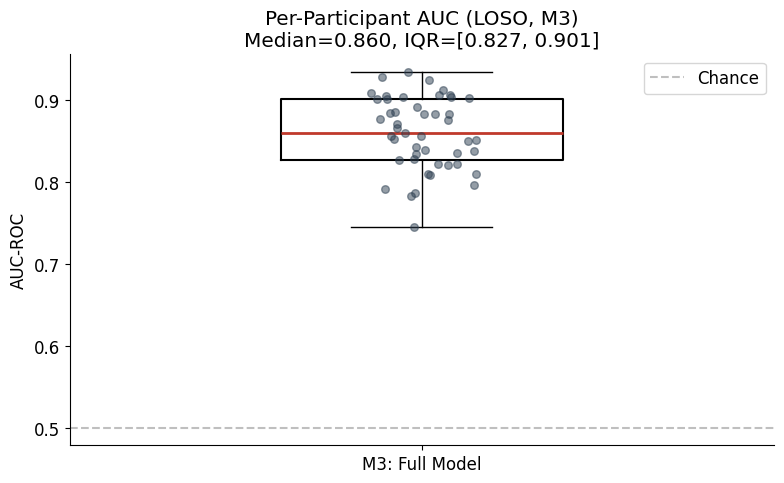

Per-participant AUC (N=47 participants with valid folds):
  Min:    0.745
  Q1:     0.827
  Median: 0.860
  Q3:     0.901
  Max:    0.934


In [6]:
loso_m3 = results['LOSO (47-fold)']['M3: Full (Pos+Dwell+Approach)']
aucs = loso_m3['auc_scores']

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(aucs, vert=True, widths=0.4, positions=[1],
           boxprops=dict(linewidth=1.5), medianprops=dict(color='#c0392b', linewidth=2))
ax.scatter(np.ones(len(aucs)) + np.random.uniform(-0.08, 0.08, len(aucs)),
           aucs, alpha=0.5, s=30, color='#2c3e50', zorder=3)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
ax.set_ylabel('AUC-ROC')
ax.set_title(f'Per-Participant AUC (LOSO, M3)\n'
             f'Median={np.median(aucs):.3f}, IQR=[{np.percentile(aucs, 25):.3f}, {np.percentile(aucs, 75):.3f}]')
ax.set_xticks([1])
ax.set_xticklabels(['M3: Full Model'])
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / 'plot21_loso_auc_distribution.png', dpi=150)
plt.show()

print(f"Per-participant AUC (N={len(aucs)} participants with valid folds):")
print(f"  Min:    {aucs.min():.3f}")
print(f"  Q1:     {np.percentile(aucs, 25):.3f}")
print(f"  Median: {np.median(aucs):.3f}")
print(f"  Q3:     {np.percentile(aucs, 75):.3f}")
print(f"  Max:    {aucs.max():.3f}")

## 6. Model Comparison (Paper Figure 4)

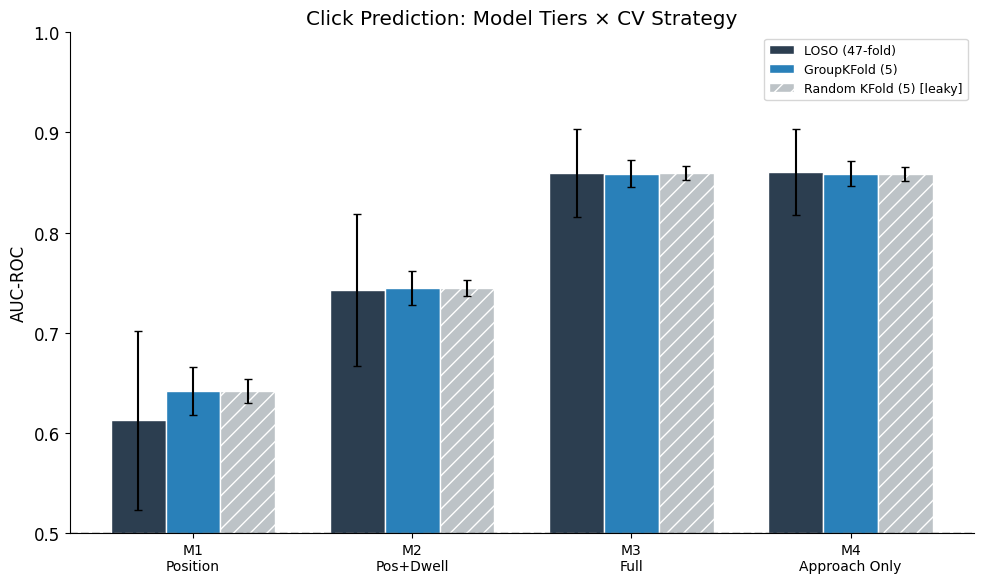

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

model_names = [m[0] for m in model_tiers]
x = np.arange(len(model_names))
width = 0.25

for i, (cv_name, color, hatch) in enumerate([
    ('LOSO (47-fold)', '#2c3e50', ''),
    ('GroupKFold (5)', '#2980b9', ''),
    ('Random KFold (5) [leaky]', '#bdc3c7', '//'),
]):
    means = [results[cv_name][m]['auc_scores'].mean() for m in model_names]
    stds = [results[cv_name][m]['auc_scores'].std() for m in model_names]
    bars = ax.bar(x + i*width, means, width, yerr=stds, label=cv_name,
                  color=color, hatch=hatch, edgecolor='white', capsize=3)

ax.set_ylabel('AUC-ROC')
ax.set_title('Click Prediction: Model Tiers × CV Strategy')
ax.set_xticks(x + width)
ax.set_xticklabels(['M1\nPosition', 'M2\nPos+Dwell', 'M3\nFull', 'M4\nApproach Only'],
                    fontsize=10)
ax.legend(fontsize=9)
ax.set_ylim(0.5, 1.0)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'plot21_model_comparison.png', dpi=150)
plt.show()

## 7. Feature Importance

Logistic regression coefficients from full-data refit (descriptive — for paper narrative). Standardized features so magnitudes are comparable.

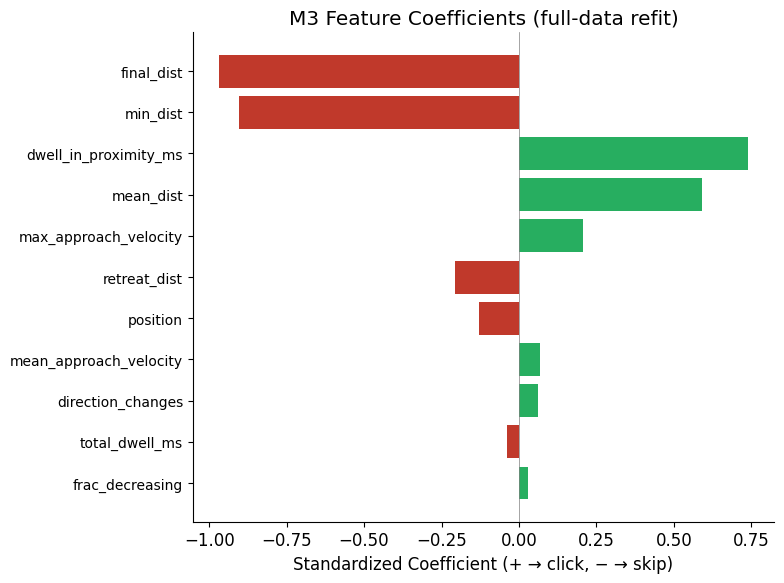

Coefficients (sorted by |value|):
  final_dist                    : -0.967 → skip
  min_dist                      : -0.904 → skip
  dwell_in_proximity_ms         : +0.738 → click
  mean_dist                     : +0.589 → click
  max_approach_velocity         : +0.207 → click
  retreat_dist                  : -0.206 → skip
  position                      : -0.130 → skip
  mean_approach_velocity        : +0.069 → click
  direction_changes             : +0.061 → click
  total_dwell_ms                : -0.040 → skip
  frac_decreasing               : +0.031 → click


In [8]:
pipe_full = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])
pipe_full.fit(X_m3, y)
coefs = pipe_full.named_steps['clf'].coef_[0]

# Sort by absolute value
feat_names = FEATURES_M3
order = np.argsort(np.abs(coefs))
sorted_names = [feat_names[i] for i in order]
sorted_coefs = coefs[order]

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#27ae60' if c > 0 else '#c0392b' for c in sorted_coefs]
ax.barh(range(len(sorted_coefs)), sorted_coefs, color=colors)
ax.set_yticks(range(len(sorted_names)))
ax.set_yticklabels(sorted_names, fontsize=10)
ax.set_xlabel('Standardized Coefficient (+ → click, − → skip)')
ax.set_title('M3 Feature Coefficients (full-data refit)')
ax.axvline(0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'plot21_feature_coefficients.png', dpi=150)
plt.show()

print("Coefficients (sorted by |value|):")
for name, coef in zip(reversed(sorted_names), reversed(sorted_coefs)):
    direction = "→ click" if coef > 0 else "→ skip"
    print(f"  {name:30s}: {coef:+.3f} {direction}")

## 8. Calibration Curve

Are the predicted probabilities meaningful? A well-calibrated model means p=0.3 corresponds to ~30% actual click rate. This matters for the threshold analysis.

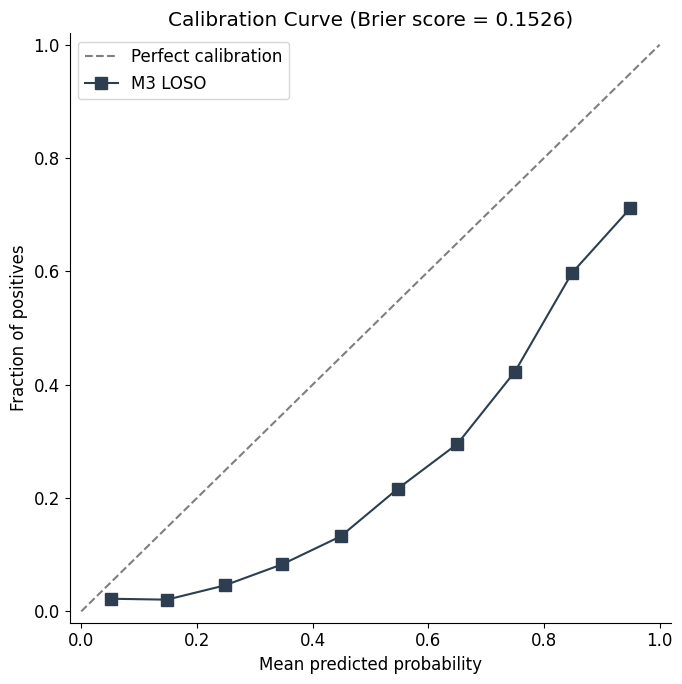

Brier score: 0.1526 (lower = better calibrated)


In [9]:
loso_m3 = results['LOSO (47-fold)']['M3: Full (Pos+Dwell+Approach)']
y_true = loso_m3['y_true']
y_pred = loso_m3['y_pred_proba']

# Remove any NaN predictions (from single-class folds)
valid = ~np.isnan(y_pred)
y_t, y_p = y_true[valid], y_pred[valid]

fraction_pos, mean_pred = calibration_curve(y_t, y_p, n_bins=10, strategy='uniform')
brier = brier_score_loss(y_t, y_p)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
ax.plot(mean_pred, fraction_pos, 's-', color='#2c3e50', markersize=8, label='M3 LOSO')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title(f'Calibration Curve (Brier score = {brier:.4f})')
ax.legend()
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'plot21_calibration.png', dpi=150)
plt.show()

print(f"Brier score: {brier:.4f} (lower = better calibrated)")

## 9. Threshold Analysis (Tautology Fix)

The four-class taxonomy currently defines "approached-rejected" as `approached AND NOT clicked` — making 0% click rate tautological. Here we replace the post-hoc split with a learned threshold from the classifier's predicted probabilities.

At the optimal threshold, non-clicked approached results are reclassified:
- `p_click > threshold` → **deferred candidate** (model thinks plausible click)
- `p_click ≤ threshold` → **evaluated-rejected** (empirically defined hard negative)

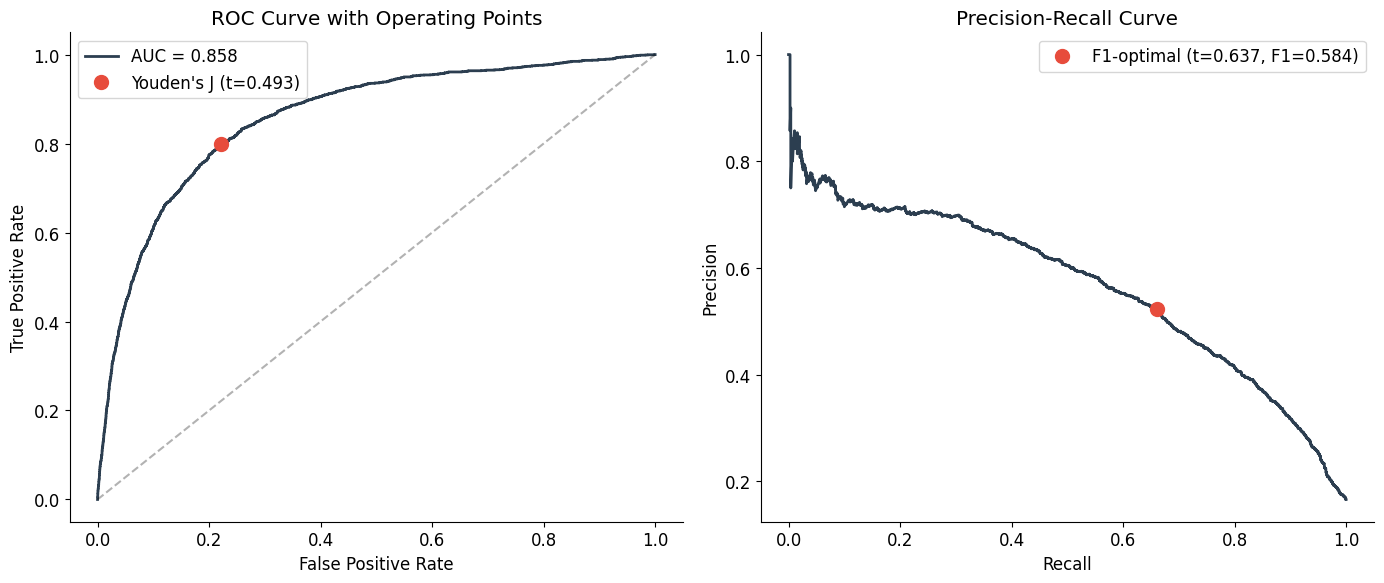

Youden's J threshold: 0.493
  TPR=0.798, FPR=0.222
F1-optimal threshold: 0.637
  F1=0.584


In [10]:
# ROC with operating points
fpr, tpr, thresholds_roc = roc_curve(y_t, y_p)

# Youden's J
j_scores = tpr - fpr
j_idx = np.argmax(j_scores)
j_threshold = thresholds_roc[j_idx]

# F1-optimal threshold
precisions_f1, recalls_f1, thresholds_f1 = precision_recall_curve(y_t, y_p)
f1_scores = 2 * precisions_f1[:-1] * recalls_f1[:-1] / (precisions_f1[:-1] + recalls_f1[:-1] + 1e-10)
f1_idx = np.argmax(f1_scores)
f1_threshold = thresholds_f1[f1_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ROC
overall_auc = roc_auc_score(y_t, y_p)
ax1.plot(fpr, tpr, color='#2c3e50', linewidth=2, label=f'AUC = {overall_auc:.3f}')
ax1.plot(fpr[j_idx], tpr[j_idx], 'o', color='#e74c3c', markersize=10,
         label=f"Youden's J (t={j_threshold:.3f})")
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve with Operating Points')
ax1.legend()

# Precision-Recall
ax2.plot(recalls_f1, precisions_f1, color='#2c3e50', linewidth=2)
ax2.plot(recalls_f1[f1_idx], precisions_f1[f1_idx], 'o', color='#e74c3c', markersize=10,
         label=f'F1-optimal (t={f1_threshold:.3f}, F1={f1_scores[f1_idx]:.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend()

plt.tight_layout()
plt.savefig(PLOT_DIR / 'plot21_roc_operating_points.png', dpi=150)
plt.show()

print(f"Youden's J threshold: {j_threshold:.3f}")
print(f"  TPR={tpr[j_idx]:.3f}, FPR={fpr[j_idx]:.3f}")
print(f"F1-optimal threshold: {f1_threshold:.3f}")
print(f"  F1={f1_scores[f1_idx]:.3f}")

In [11]:
# Apply learned threshold to reclassify non-clicked approached results
# "Approached" = min_dist < 100px (same definition as notebook 15)

threshold = j_threshold  # Use Youden's J as primary

approached = np.array([r['min_dist'] < 100 for r in raw])
clicked = y.astype(bool)

# Compute full OOF prediction vector and classifier-derived taxonomy
y_p_full = loso_m3['y_pred_proba'].copy()

cat = np.full(n, '', dtype='U30')
cat[clicked] = 'Clicked'
has_pred = ~np.isnan(y_p_full)
nc_appr_pred = ~clicked & approached & has_pred
cat[nc_appr_pred & (y_p_full > threshold)] = 'Deferred candidate'
cat[nc_appr_pred & (y_p_full <= threshold)] = 'Evaluated-rejected'
cat[cat == ''] = 'No signal'

# Count
from collections import Counter
counts = Counter(cat)
print("=== Classifier-Derived Taxonomy (Tautology Fix) ===")
print(f"Threshold: {threshold:.3f} (Youden's J)")
print()
for label in ['Clicked', 'Deferred candidate', 'Evaluated-rejected', 'No signal']:
    c = counts[label]
    pct = c / n * 100
    # Mean predicted click probability for this class
    mask = cat == label
    if has_pred[mask].any():
        mean_p = np.nanmean(y_p_full[mask])
        print(f"  {label:25s}: {c:6,} ({pct:5.1f}%)  mean p(click) = {mean_p:.3f}")
    else:
        print(f"  {label:25s}: {c:6,} ({pct:5.1f}%)")

print()
print("Compare to post-hoc counts from notebook 15:")
print("  Clicked:             1,981")
print("  Approached-rejected: 2,280 (was tautological 0%)")
print("  Peripherally seen:   4,548")
print("  Unseen:              6,588")

=== Classifier-Derived Taxonomy (Tautology Fix) ===
Threshold: 0.493 (Youden's J)

  Clicked                  :  2,228 ( 16.6%)  mean p(click) = 0.690
  Deferred candidate       :  1,381 ( 10.3%)  mean p(click) = 0.709
  Evaluated-rejected       :    974 (  7.3%)  mean p(click) = 0.313
  No signal                :  8,836 ( 65.8%)  mean p(click) = 0.247

Compare to post-hoc counts from notebook 15:
  Clicked:             1,981
  Approached-rejected: 2,280 (was tautological 0%)
  Peripherally seen:   4,548
  Unseen:              6,588


## 10. Confusion Matrices

Binary classifier confusion at Youden's J, plus a three-class predicted-category
× actual-click validation table. The three-class table is the honest companion
to §9's four-class taxonomy: it uses only cursor approach + classifier
probability to define categories (no click label), so the observed click rate
per row is a held-out validation of the hard-negative framing.


BINARY CONFUSION MATRIX — LOSO M3, Youden's J threshold
Threshold: 0.493   |   N pooled: 13,419

                   Predicted no-click   Predicted click
  True no-click               8,706             2,485
  True click                    449             1,779

  TPR (sensitivity): 0.798   FPR: 0.222
  TNR (specificity): 0.778   Precision: 0.417
  Accuracy:          0.781   Balanced acc: 0.788

PREDICTED-CATEGORY × ACTUAL-CLICK VALIDATION
(Categories derived from cursor approach + classifier probability;
 click outcome is the held-out label. Rejected = hard negative.)

  Category            N    Clicked   Click rate
  ----------------------------------------------
  Promising       2,701      1,320       48.87%
  Rejected        1,082        108        9.98%
  No signal       9,636        800        8.30%
  ----------------------------------------------
  TOTAL          13,419      2,228       16.60%

Hard-negative interpretation: the 'Rejected' row is the set of results
the cursor app

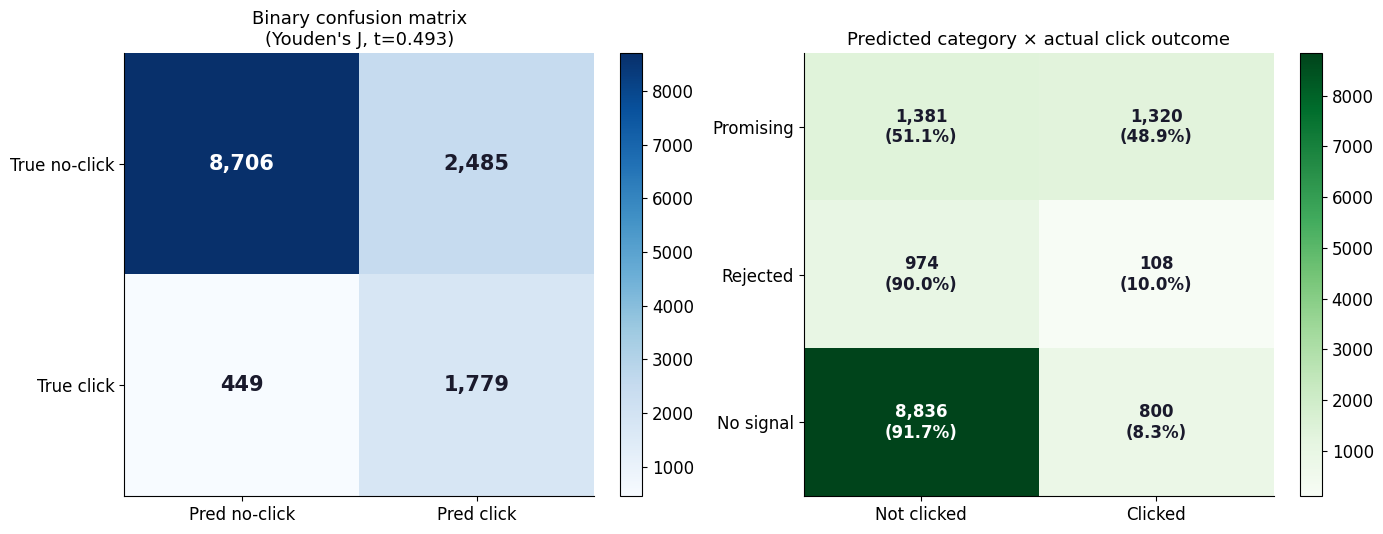

In [12]:
# Confusion matrices — binary at Youden's J, plus taxonomy-vs-outcome validation.
from sklearn.metrics import confusion_matrix

# -------- 1. Binary confusion matrix at Youden's J threshold --------
y_pred_bin = (y_p >= j_threshold).astype(int)
cm_bin = confusion_matrix(y_t, y_pred_bin)
tn, fp, fn, tp = cm_bin.ravel()
total = tn + fp + fn + tp

print("=" * 62)
print("BINARY CONFUSION MATRIX — LOSO M3, Youden's J threshold")
print("=" * 62)
print(f"Threshold: {j_threshold:.3f}   |   N pooled: {total:,}")
print()
print("                   Predicted no-click   Predicted click")
print(f"  True no-click    {tn:>16,}   {fp:>15,}")
print(f"  True click       {fn:>16,}   {tp:>15,}")
print()
print(f"  TPR (sensitivity): {tp/(tp+fn):.3f}   FPR: {fp/(fp+tn):.3f}")
print(f"  TNR (specificity): {tn/(tn+fp):.3f}   Precision: {tp/(tp+fp):.3f}")
print(f"  Accuracy:          {(tp+tn)/total:.3f}   Balanced acc: {(tp/(tp+fn) + tn/(tn+fp))/2:.3f}")
print()

# -------- 2. Three-class predicted-category × actual-click table --------
# Predicted categories use ONLY cursor-approach + classifier probability,
# NOT the click label — the published four-class taxonomy uses click as a
# top-level split, which would be tautological for a confusion matrix.
predicted_cat = np.full(n, 'No signal', dtype='U20')
valid = has_pred
predicted_cat[valid & approached & (y_p_full >  j_threshold)] = 'Promising'
predicted_cat[valid & approached & (y_p_full <= j_threshold)] = 'Rejected'
# not-approached and invalid predictions remain 'No signal'

print("=" * 62)
print("PREDICTED-CATEGORY × ACTUAL-CLICK VALIDATION")
print("=" * 62)
print("(Categories derived from cursor approach + classifier probability;")
print(" click outcome is the held-out label. Rejected = hard negative.)")
print()
print(f"  {'Category':<12s} {'N':>8s} {'Clicked':>10s} {'Click rate':>12s}")
print("  " + "-" * 46)
labels3 = ['Promising', 'Rejected', 'No signal']
counts3 = np.zeros((3, 2), dtype=int)  # rows: category, cols: [not-clicked, clicked]
for i, L in enumerate(labels3):
    mask = predicted_cat == L
    counts3[i, 0] = int((mask & ~clicked).sum())
    counts3[i, 1] = int((mask &  clicked).sum())
    n_cat = counts3[i].sum()
    n_click = counts3[i, 1]
    rate = n_click / n_cat * 100 if n_cat else 0.0
    print(f"  {L:<12s} {n_cat:>8,} {n_click:>10,} {rate:>11.2f}%")
print("  " + "-" * 46)
total_click = int(clicked.sum())
print(f"  {'TOTAL':<12s} {n:>8,} {total_click:>10,} {total_click/n*100:>11.2f}%")
print()
print("Hard-negative interpretation: the 'Rejected' row is the set of results")
print("the cursor approached (<100px) but the classifier labeled as unlikely")
print("to click. A click rate in this row well below the overall rate")
print(f"({total_click/n*100:.2f}%) validates the hard-negative framing.")

# -------- 3. Side-by-side heatmaps --------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Binary CM heatmap
ax = axes[0]
im0 = ax.imshow(cm_bin, cmap='Blues', aspect='auto')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred no-click', 'Pred click'])
ax.set_yticklabels(['True no-click', 'True click'])
ax.set_title(f"Binary confusion matrix\n(Youden's J, t={j_threshold:.3f})", fontsize=13)
vmax = cm_bin.max()
for i in range(2):
    for j in range(2):
        val = cm_bin[i, j]
        color = 'white' if val > vmax * 0.55 else '#1a1a2c'
        ax.text(j, i, f'{val:,}', ha='center', va='center', fontsize=15,
                color=color, fontweight='bold')
plt.colorbar(im0, ax=ax, fraction=0.046)

# 3-class × 2-outcome table
ax = axes[1]
im1 = ax.imshow(counts3, cmap='Greens', aspect='auto')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1, 2])
ax.set_xticklabels(['Not clicked', 'Clicked'])
ax.set_yticklabels(labels3)
ax.set_title("Predicted category × actual click outcome", fontsize=13)
vmax3 = counts3.max()
for i in range(3):
    row_total = counts3[i].sum()
    for j in range(2):
        val = counts3[i, j]
        pct = val / row_total * 100 if row_total else 0.0
        color = 'white' if val > vmax3 * 0.55 else '#1a1a2c'
        ax.text(j, i, f'{val:,}\n({pct:.1f}%)', ha='center', va='center',
                fontsize=12, color=color, fontweight='bold')
plt.colorbar(im1, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'plot21_confusion_matrices.png', dpi=150)
plt.show()


## 11. Paper-Ready Summary

In [13]:
print("=" * 70)
print("PAPER §3.5 / §4.3 — UPDATED NUMBERS")
print("=" * 70)
print()
print("Cross-validation: LOSO (47-fold, following Huang et al. CHI 2012)")
print("Pipeline: StandardScaler → LogisticRegression(balanced)")
print()

for model_name, _ in model_tiers:
    r = results['LOSO (47-fold)'][model_name]
    print(f"  {model_name:35s}: AUC {r['auc_scores'].mean():.3f} ± {r['auc_scores'].std():.3f}"
          f"  |  AP {r['ap_scores'].mean():.3f} ± {r['ap_scores'].std():.3f}"
          f"  ({r['n_valid_folds']} valid folds)")

print()
print("Per-participant generalization (LOSO M3):")
aucs = results['LOSO (47-fold)']['M3: Full (Pos+Dwell+Approach)']['auc_scores']
print(f"  Median AUC: {np.median(aucs):.3f}")
print(f"  IQR: [{np.percentile(aucs, 25):.3f}, {np.percentile(aucs, 75):.3f}]")
print(f"  Range: [{aucs.min():.3f}, {aucs.max():.3f}]")
print()

# Leakage comparison
for model_name, _ in model_tiers:
    loso_auc = results['LOSO (47-fold)'][model_name]['auc_scores'].mean()
    rand_auc = results['Random KFold (5) [leaky]'][model_name]['auc_scores'].mean()
    delta = rand_auc - loso_auc
    print(f"  Leakage Δ {model_name:35s}: {delta:+.3f}")

print()
print(f"Threshold for taxonomy (Youden's J): {j_threshold:.3f}")
print()
print("=" * 70)

PAPER §3.5 / §4.3 — UPDATED NUMBERS

Cross-validation: LOSO (47-fold, following Huang et al. CHI 2012)
Pipeline: StandardScaler → LogisticRegression(balanced)

  M1: Position                       : AUC 0.613 ± 0.090  |  AP 0.238 ± 0.071  (47 valid folds)
  M2: Position + Dwell               : AUC 0.743 ± 0.076  |  AP 0.433 ± 0.094  (47 valid folds)
  M3: Full (Pos+Dwell+Approach)      : AUC 0.859 ± 0.044  |  AP 0.611 ± 0.097  (47 valid folds)
  M4: Approach Only                  : AUC 0.861 ± 0.043  |  AP 0.612 ± 0.096  (47 valid folds)

Per-participant generalization (LOSO M3):
  Median AUC: 0.860
  IQR: [0.827, 0.901]
  Range: [0.745, 0.934]

  Leakage Δ M1: Position                       : +0.029
  Leakage Δ M2: Position + Dwell               : +0.002
  Leakage Δ M3: Full (Pos+Dwell+Approach)      : -0.000
  Leakage Δ M4: Approach Only                  : -0.002

Threshold for taxonomy (Youden's J): 0.493

